# **NLP AND ML ON DISASTER TWEETS**

### *The goal is to build a machine learning model that predicts which Tweets are about real disasters and which one’s aren’t.*

## **STEP 1: Data Wrangling**

In [1]:
#Importing required libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Loading the data
train_data = pd.read_csv("/kaggle/input/nlp-getting-started/train.csv")
test_data = pd.read_csv("/kaggle/input/nlp-getting-started/test.csv")

In [3]:
#Viewing the data for training
train_data.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In the target column, '0' indicates it is not a tweet related to disaster

In [4]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [5]:
#Removing irrelevant columns
train_data = train_data.drop(columns=['keyword', 'location'])
train_data.head()

,id,text,target
0,1,Our Deeds are the Reason of this #earthquake M...,1
1,4,Forest fire near La Ronge Sask. Canada,1
2,5,All residents asked to 'shelter in place' are ...,1
3,6,"13,000 people receive #wildfires evacuation or...",1
4,7,Just got sent this photo from Ruby #Alaska as ...,1


0    4342
1    3271
Name: target, dtype: int64


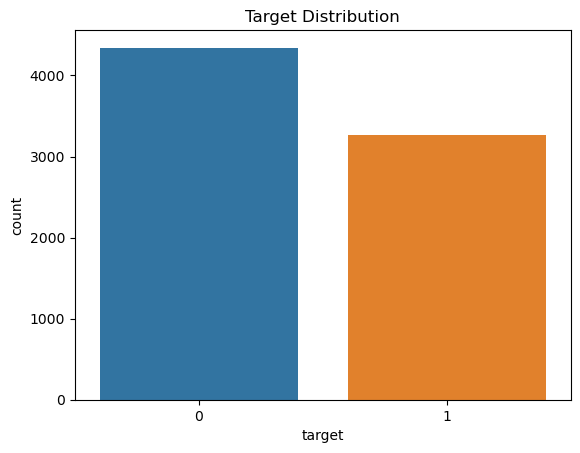

In [6]:
#Let's check the distributaion of target variable.
sns.countplot(x='target', data=train_data,)
plt.title('Target Distribution');

print(train_data['target'].value_counts())

### **Text preprocessing and Vectorization**

In [7]:
#Importing required libraris
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.snowball import SnowballStemmer
from sklearn.feature_extraction.text import TfidfVectorizer

In [8]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [9]:
#Downloading stopwords
nltk.download('stopwords')
english_stopwords = stopwords.words('english')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
#Viewing stop words
", ".join(english_stopwords)

"i, me, my, myself, we, our, ours, ourselves, you, you're, you've, you'll, you'd, your, yours, yourself, yourselves, he, him, his, himself, she, she's, her, hers, herself, it, it's, its, itself, they, them, their, theirs, themselves, what, which, who, whom, this, that, that'll, these, those, am, is, are, was, were, be, been, being, have, has, had, having, do, does, did, doing, a, an, the, and, but, if, or, because, as, until, while, of, at, by, for, with, about, against, between, into, through, during, before, after, above, below, to, from, up, down, in, out, on, off, over, under, again, further, then, once, here, there, when, where, why, how, all, any, both, each, few, more, most, other, some, such, no, nor, not, only, own, same, so, than, too, very, s, t, can, will, just, don, don't, should, should've, now, d, ll, m, o, re, ve, y, ain, aren, aren't, couldn, couldn't, didn, didn't, doesn, doesn't, hadn, hadn't, hasn, hasn't, haven, haven't, isn, isn't, ma, mightn, mightn't, mustn, mus

In [11]:
#Stemming
stemmer = SnowballStemmer(language = 'english')

In [12]:
#Defining a function for stemming
def tokenize(text):
  return [stemmer.stem(token) for token in word_tokenize(text) if token.isalpha()]

In [13]:
#Vectorization
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train_data['text'])
y_train = train_data['target']
X_test = vectorizer.transform(test_data['text'])

## **STEP 2: Model Training**

In [14]:
#Importing required libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [15]:
#Splitting train data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [16]:
# Train logistic regression model
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)

LogisticRegression(random_state=42)

## **STEP 3: Evaluation**

In [17]:
# Predict on validation set and calculate accuracy
from sklearn.metrics import accuracy_score

y_pred_val = lr_model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_pred_val)
print('Validation accuracy:', val_accuracy)

Validation accuracy: 0.8003939592908733


The accuracy I got is 80%. This is my first attempt on 'Natural Language Processing', and I will definitely do better asap.

In [18]:
#Predictions on test set
y_pred_test = lr_model.predict(X_test)

In [19]:
submission = pd.DataFrame({'id': test_data['id'], 'target': y_pred_test})
submission.to_csv('submission.csv', index=False)